In [113]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib import pyplot as plt
import copy
from netCDF4 import Dataset, num2date, date2num

from scipy import arange, cos, exp
from scipy.interpolate import RegularGridInterpolator
from numpy import unique
from numpy import where
from sklearn.datasets import make_classification

from sklearn import datasets
from sklearn import metrics
from matplotlib import pyplot
import matplotlib.patches as patches
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from haversine import haversine, Unit
import xarray as xr
import seaborn as sns
from scipy.stats import rankdata
from matplotlib import colors as c
import csv

from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from matplotlib.colors import from_levels_and_colors
import random
import cmaps
from scipy import signal
from datetime import datetime
from scipy.stats import stats
import xarray as xr

import geopandas as gpd
import pandas as pd
import matplotlib.colors as colors
import scipy
import scipy.stats

from statsmodels.nonparametric.smoothers_lowess import lowess

from scipy import interpolate
from scipy.stats import linregress

In [114]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.datasets import load_boston
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, make_scorer

from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.datasets import load_boston
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,explained_variance_score


def custom_objective(preds, train_data):
    labels = train_data.get_label()
    residual = (labels - preds).astype("float")
    grad = -2 * residual
    hess = 2 * np.ones_like(labels)
    return grad, hess
def custom_r2_metric(preds, train_data):
    labels = train_data.get_label()
    r2 = r2_score(labels, preds)
    return 'r2', r2, True
# Define the custom quantile loss function for scoring
def quantile_loss(y_true, y_pred, alpha=0.9):
    diff = y_true - y_pred
    return np.mean(np.maximum(alpha * diff, (alpha - 1) * diff))

# Create a custom scorer using make_scorer
quantile_loss_scorer = make_scorer(quantile_loss, greater_is_better=False, alpha=0.9)

In [115]:
from scipy.stats import theilslopes
from statsmodels.nonparametric.smoothers_lowess import lowess

# Etesians

In [116]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_V850_1.x1._3daymean.nc') #current shape = (365, 180,360)

V850 = np.squeeze(NCData.variables['var132'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

# NCData.close()

In [117]:
X_std = copy.deepcopy(V850)
for i_mon in set(mon_era5_all):
    mu  = np.nanmean(X_std[mon_era5_all==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all==i_mon] = X_std[mon_era5_all==i_mon] -mu

for i_year in set(year_era5_all):
    mu  = np.nanmean(X_std[year_era5_all==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all==i_year] = X_std[year_era5_all==i_year] -mu
    
V850_std =copy.deepcopy( X_std)
del X_std
# del Z500

In [118]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/Etesisans_1950_2025_3d_allyear.npy') #current shape = (365, 180,360)
Etesians = np.squeeze(NCData.variables['var132'][:])
NCData.close()

In [119]:
Etesians_index = -np.array([np.nanmean(i) for i in Etesians])

In [111]:
np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/Etesians_index_1950_2025_3d_allyear.npy',Etesians_index)

In [120]:
X_std = copy.deepcopy(Etesians_index)
for i_mon in set(mon_era5_all):
    mu  = np.nanmean(X_std[mon_era5_all==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all==i_mon] = X_std[mon_era5_all==i_mon] -mu

for i_year in set(year_era5_all):
    mu  = np.nanmean(X_std[year_era5_all==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all==i_year] = X_std[year_era5_all==i_year] -mu
Etesians_index_std =copy.deepcopy( X_std)
del X_std

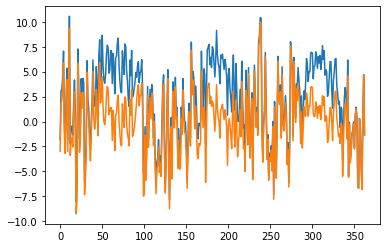

In [121]:
plt.plot(Etesians_index[:121*3])
plt.plot(Etesians_index_std[:121*3])

In [122]:
SNAO_index= np.load('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_allyear.npy',allow_pickle='True')

In [123]:
X_std = copy.deepcopy(SNAO_index)
for i_mon in set(mon_era5_all):
    mu  = np.nanmean(X_std[mon_era5_all==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all==i_mon] = X_std[mon_era5_all==i_mon] -mu

for i_year in set(year_era5_all):
    mu  = np.nanmean(X_std[year_era5_all==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all==i_year] = X_std[year_era5_all==i_year] -mu
SNAO_index_std =copy.deepcopy( X_std)
del X_std

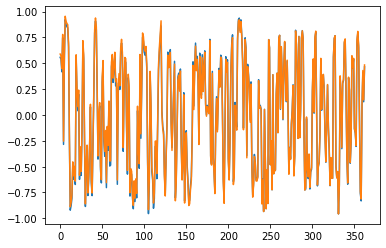

In [124]:
plt.plot(SNAO_index[:121*3])
plt.plot(SNAO_index_std[:121*3])

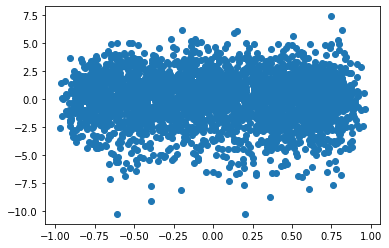

In [125]:
plt.scatter(SNAO_index_std[np.in1d(mon_era5_all,[6,7,8,9])],Etesians_index_std[np.in1d(mon_era5_all,[6,7,8,9])])

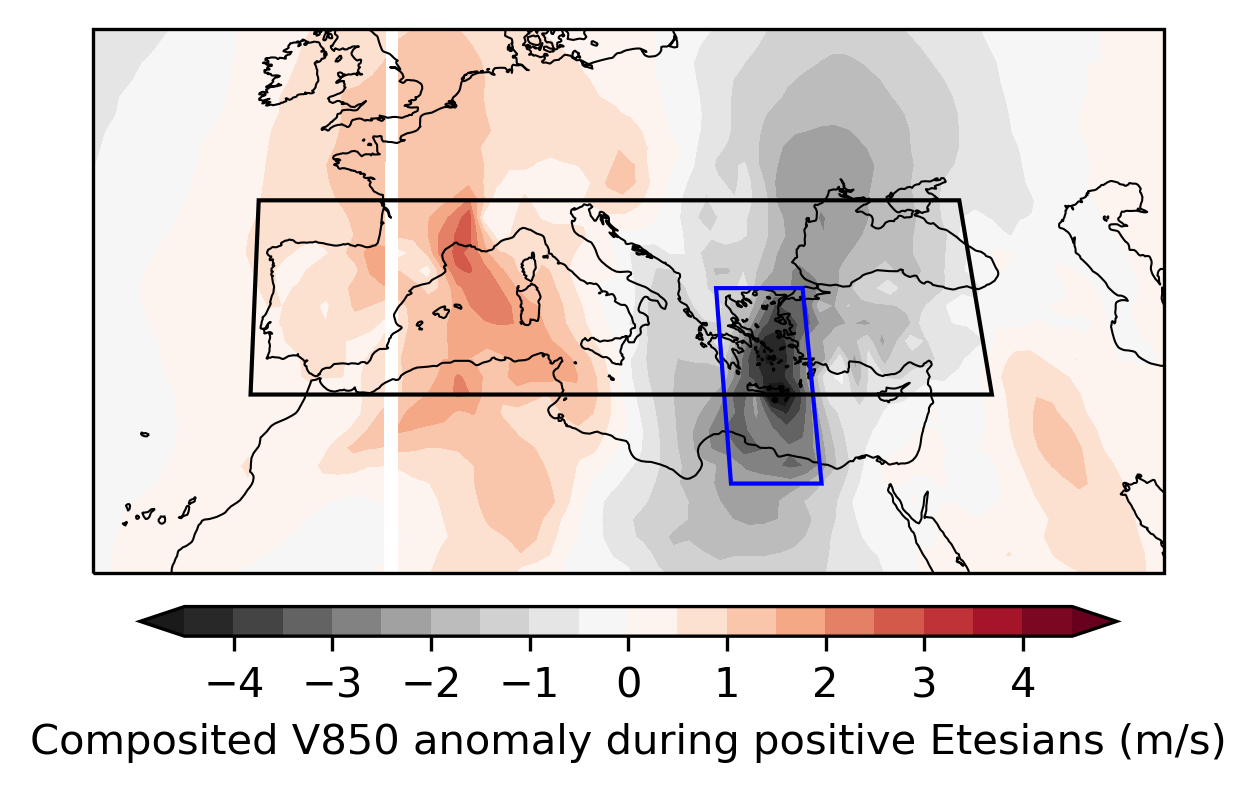

In [129]:
lon_min1 = 22
lat_min1 = 30              
lon_max1 = 28
lat_max1 = 41           
lon_min, lon_max = -10, 40
lat_min, lat_max = 35, 46

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)
lag = 0          # -1 = one timestep BEFORE the extreme, +1 = after


Index_temp = Etesians_index[np.in1d(mon_era5_all,[6,7,8,9])]
Index_temp = (Index_temp-np.nanmean(Index_temp))/np.nanstd(Index_temp)
Index_temp_thr = 1

mask_ext = Index_temp > Index_temp_thr                # extreme at time t


Z = V850_std[np.in1d(mon_era5_all,[6,7,8,9])]
mask_ext_lag = mask_ext

mask_non_lag = ~mask_ext_lag

# Convert to meters
Z_ext = Z[mask_ext_lag, :, :] 
Z_non = Z[mask_non_lag, :, :] 

# Composite anomaly (lagged): extreme-minus-nonextreme
temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z, axis=0)

# -------------------------
# 1) Gridpoint significance (Welch t-test)
# -------------------------
tstat, pvals = ttest_ind(
    Z_ext, Z_non,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

# Sample-size filter
n_ext = np.sum(np.isfinite(Z_ext), axis=0)
n_non = np.sum(np.isfinite(Z_non), axis=0)
valid = (n_ext >= 1) & (n_non >= 1) & np.isfinite(pvals)

# -------------------------
# 2) FDR across grid points
# -------------------------
sig_fdr = np.zeros_like(pvals, dtype=bool)
qvals = np.full_like(pvals, np.nan, dtype=float)

if np.any(valid):
    p_flat = pvals[valid].ravel()
    rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
    sig_fdr[valid] = rej
    qvals[valid] = q_flat

effect_mask =np.abs(temp_JJA)>5
sig_final = sig_fdr & effect_mask
# -------------------------
# 3) Plot
# -------------------------
fig, ax = plt.subplots(figsize=(6,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-4.5, 5, 0.5)
contour = ax.contourf(
    LON_era5, LAT_era5, temp_JJA,
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap='RdGy_r',
    extend='both'
)

ax.contourf(
    LON_era5, LAT_era5, sig_final.astype(int),
    levels=[0.5, 1.5],
    hatches=['....'],
    colors='none',
    transform=ccrs.PlateCarree()
)


rect1 = mpatches.Rectangle(
    (lon_min1, lat_min1),                 # lower-left corner
    lon_max1 - lon_min1,                  # width
    lat_max1 - lat_min1,                  # height
    linewidth=1,
    edgecolor='b',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)
ax.add_patch(rect1)

rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax.add_patch(rect)



ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=30)
co.set_label(r'Composited V850 anomaly during positive Etesians (m/s)')
ax.set_extent([lon_min-10, lon_max+10, lat_min-10, lat_max+10], crs=ccrs.PlateCarree())

plt.show()

# load data

# cal summer NAO

In [4]:

NCData = Dataset(r'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe/land_sea_mask_2023_01_01_1x1.nc')
land_mask = np.squeeze(NCData.variables['var172'][:])
lon_era5= NCData.variables['lon'][:][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
print(NCData.variables['lon'][:][:][:10])
print(NCData.variables['lat'][:][:][:10])
NCData.close()


[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[90. 89. 88. 87. 86. 85. 84. 83. 82. 81.]


In [5]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_MSLP_1.x1._3daymean.nc') #current shape = (365, 180,360)

MSLP = np.squeeze(NCData.variables['var151'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

# NCData.close()

In [6]:
import numpy as np
from netCDF4 import Dataset, num2date
from numpy.linalg import svd  # fast + stable for EOF/cov-eigenvectors

# -----------------------------
# # 1) Read data
# -----------------------------
fn = "/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_MSLP_1.x1._3daymean.nc"
NCData = Dataset(fn)

# Assumed dims: (time, lat, lon)
MSLP = np.squeeze(NCData.variables["var151"][:]).astype(np.float64)  # (T, Y, X)
lon = NCData.variables["lon"][:].astype(np.float64)                 # 0..360
lat = NCData.variables["lat"][:].astype(np.float64)                 # 90..-90 or -90..90

time_var = NCData.variables["time"]
dates = np.array(num2date(time_var[:], time_var.units, getattr(time_var, "calendar", "standard")))
years = np.array([d.year for d in dates])
months = np.array([d.month for d in dates])

NCData.close()


In [7]:

# -----------------------------
# 2) Subset: Jul-Aug 1960–2025, region 25–70N, 70W–50E
# -----------------------------
# Lat index (works regardless of lat ordering)
lat_mask = (lat >= 25) & (lat <= 70)
ilat = np.where(lat_mask)[0]

# Lon mask: 70W–50E -> lon in [290,360) U [0,50] when lon is 0..360
lon = lon % 360
lon_mask = (lon >= 290) | (lon <= 50)
ilon = np.where(lon_mask)[0]

# Time mask: July & August, years 1960–2025 inclusive
tmask = (years >= 1950) & (years <= 2025) & ((months == 7) | (months == 8))
it = np.where(tmask)[0]

# Subset data
mslp = MSLP[np.ix_(it, ilat, ilon)]  # (Nt, Ny, Nx)
lat_sub = lat[ilat]
lon_sub = lon[ilon]
Nt, Ny, Nx = mslp.shape

In [8]:


# -----------------------------
# 3) Compute anomalies relative to 1960–2025 Jul-Aug mean (single mean over all selected times)
# (This matches "relative to an 1960-2025 average of the daily ... dataset for July and August".)
# -----------------------------
# If there are missing values, make sure they are NaN
# (If your file uses a fill_value, you can replace here.)
fill = getattr(NCData.variables["var151"], "_FillValue", None)
clim = np.nanmean(mslp, axis=0)              # (Ny, Nx)
anom = mslp - clim                           # (Nt, Ny, Nx)


In [9]:

# -----------------------------
# 4) Area weights: sqrt(area of each 1x1 grid cell)
# For a regular lon-lat grid, area ∝ cos(lat). With 1x1, dlat*dlon constants -> weights ∝ sqrt(cos(lat)).
# -----------------------------
# Use radians
coslat = np.cos(np.deg2rad(lat_sub))         # (Ny,)

# Protect against tiny numerical negatives near poles (shouldn't matter for 25–70N)
coslat = np.clip(coslat, 0.0, None)

# sqrt(area) weight for each cell -> sqrt(cos(lat)) replicated across lon
w2d = np.sqrt(coslat)[:, None] * np.ones((Ny, Nx), dtype=np.float64)  # (Ny, Nx)


In [10]:

# -----------------------------
# 5) Build weighted anomaly matrix and compute first covariance eigenvector (EOF1)
# X: (Nt, Nspace). Weight columns by sqrt(area): Xw = X * w
# Do SVD of Xw (equivalent to eigen-decomp of covariance).
# -----------------------------
X = anom.reshape(Nt, Ny * Nx)     # (Nt, Ns)
w = w2d.reshape(Ny * Nx)          # (Ns,)

# Remove any all-NaN gridpoints (if needed)
valid = np.isfinite(np.nanmean(X, axis=0))
Xv = X[:, valid]
wv = w[valid]

# Replace remaining NaNs in time with column-wise mean (or 0) — choose a simple, stable option:
col_mean = np.nanmean(Xv, axis=0)
inds = np.where(~np.isfinite(Xv))
Xv[inds] = np.take(col_mean, inds[1])

# Demean across time again (after NaN handling) to be safe
Xv = Xv - Xv.mean(axis=0, keepdims=True)

# Apply sqrt(area) weights to columns
Xw = Xv * wv[None, :]  # (Nt, Ns_valid)

# SVD: Xw = U S Vt
U, S, Vt = svd(Xw, full_matrices=False)

# First covariance eigenvector in weighted space:
eof1_w = Vt[0, :]              # (Ns_valid,)
pc1 = U[:, 0] * S[0]           # PC time series (scaled)

# Convert EOF back to physical-space pattern (remove weights):
eof1 = eof1_w / wv             # (Ns_valid,)

# Optional: scale EOF to match "MSLP pattern per 1 std of PC1"
pc1_std = pc1.std(ddof=1)
eof1_scaled = eof1 * pc1_std   # now units ~ Pa (if input is Pa)

# Put back into full (Ny*Nx) with NaNs where invalid
EOF1_map = np.full(Ny * Nx, np.nan, dtype=np.float64)
EOF1_map[valid] = eof1_scaled
EOF1_map = EOF1_map.reshape(Ny, Nx)  # (Ny, Nx)

# Optional sign convention (NAO: typically negative over Iceland / positive over Azores).
# Here: enforce EOF average over (lat 60–70N, lon 300–360/0–20) to be NEGATIVE (Icelandic Low region).
# Adjust boxes as you like.
# def lon_in_box(lon_arr, lo, hi):
#     lon_arr = lon_arr % 360
#     lo, hi = lo % 360, hi % 360
#     if lo <= hi:
#         return (lon_arr >= lo) & (lon_arr <= hi)
#     else:
#         return (lon_arr >= lo) | (lon_arr <= hi)

# lat_box = (lat_sub >= 60) & (lat_sub <= 70)
# lon_box = lon_in_box(lon_sub, 300, 20)  # wraps across 360
# if np.nanmean(EOF1_map[np.ix_(lat_box, lon_box)]) > 0:
#     EOF1_map *= -1
#     pc1 *= -1

# Optional sign convention (SNAO: typically negative over Arctic / positive over northwestern Europe).
# Here: enforce EOF average over (lat 50-60N, lon 350–360/0–30) to be POSITVE (northwestern Europe).
# Adjust boxes as you like.
def lon_in_box(lon_arr, lo, hi):
    lon_arr = lon_arr % 360
    lo, hi = lo % 360, hi % 360
    if lo <= hi:
        return (lon_arr >= lo) & (lon_arr <= hi)
    else:
        return (lon_arr >= lo) | (lon_arr <= hi)

lat_box = (lat_sub >= 60) & (lat_sub <= 70)
lon_box = lon_in_box(lon_sub, 350, 30)  # wraps across 360
if np.nanmean(EOF1_map[np.ix_(lat_box, lon_box)]) < 0:
    EOF1_map *= -1
    pc1 *= -1


# Explained variance (fraction) from singular values:
# For covariance of Xw: eigenvalues = S^2/(Nt-1)
eigvals = (S**2) / (Nt - 1)
varfrac1 = eigvals[0] / np.sum(eigvals)

print(f"EOF1 explained variance (weighted covariance): {varfrac1:.3f}")
print("EOF1_map shape:", EOF1_map.shape)
print("PC1 length:", pc1.shape[0])


EOF1 explained variance (weighted covariance): 0.177
EOF1_map shape: (46, 121)
PC1 length: 1596


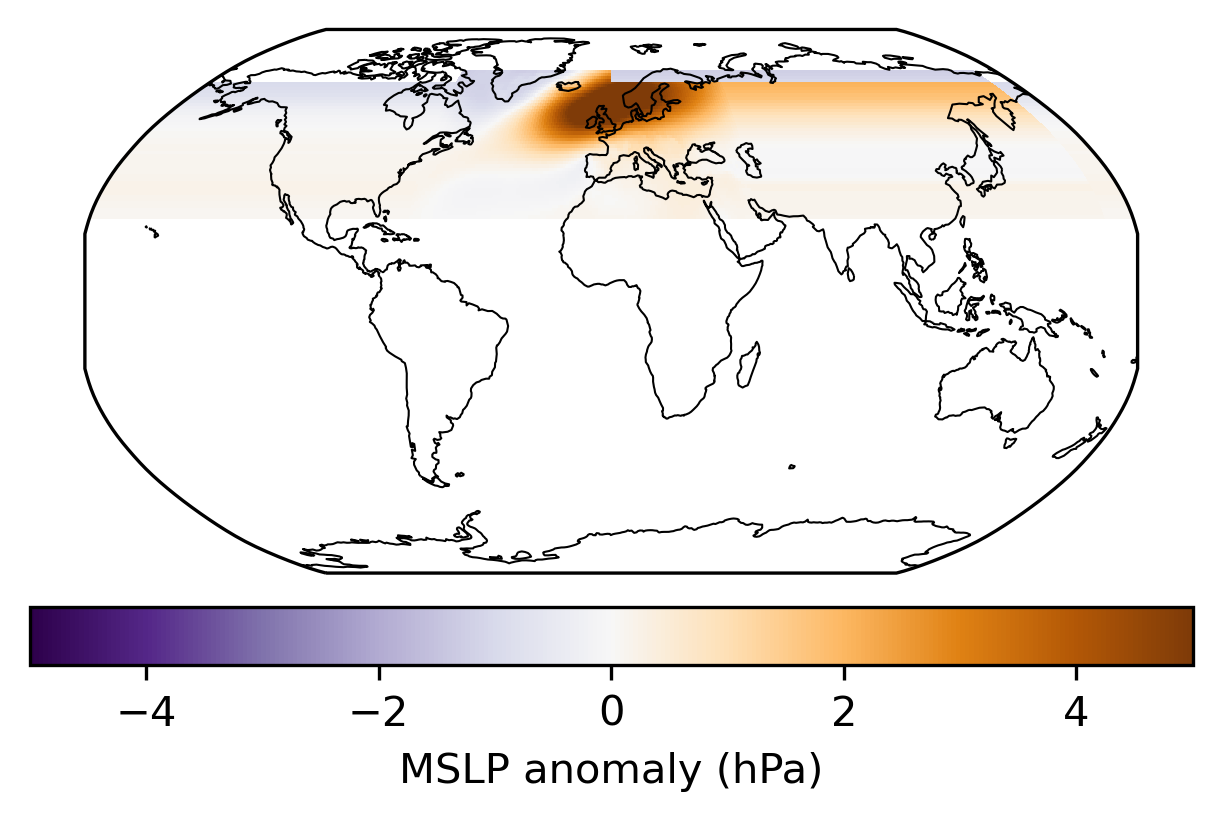

In [11]:


# -------------------------
# 3) Plot: field + hatching where FDR-significant
# -------------------------
fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-5, 5.5, 0.5)
contour = ax.pcolormesh(
    lon_sub, lat_sub,EOF1_map/100,
    vmin=levels[0],
    vmax=levels[-1],
    transform=ccrs.PlateCarree(),
    cmap='PuOr_r',

)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
co.set_label(r'MSLP anomaly (hPa)')
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

plt.show()


In [12]:

# -----------------------------
# # Outputs:
# # EOF1_map : (Ny, Nx) NAO pattern (units ~ MSLP, scaled per 1 std PC1)
# # pc1 : (Nt,) NAO index time series for Jul-Aug 1960–2025 (3-day means)
# # lat_sub, lon_sub : coordinates for plotting
# -----------------------------
# Example: if you want a simple NAO index normalized:
nao_index = (pc1 - pc1.mean()) / pc1.std(ddof=1)

# # Save results if needed (np.savez)
# np.savez("HSNAO_EOF1_ERA5_MSLP_JA_1960_2025_25-70N_70W-50E.npz",
# EOF1_map=EOF1_map, PC1=pc1, NAO=nao_index, lat=lat_sub, lon=lon_sub, dates=dates[it].astype("datetime64[s]"))

#  MSLP PLOT

In [ ]:
# # NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_Z500_1.x1._3daymean.nc') #current shape = (365, 180,360)

# Z500 = np.squeeze(NCData.variables['var129'][:])
# lon_era5= NCData.variables['lon'][:]
# lat_era5 = NCData.variables['lat'][:]
# LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
# time = NCData.variables['time']
# dates = list(num2date(time[:], time.units, time.calendar))
# year_era5_all = np.array([date.year for date in dates])
# mon_era5_all = np.array([date.month for date in dates])
# day_era5_all = np.array([date.day for date in dates])

# NCData.close()



In [105]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_MSLP_1.x1._3daymean.nc') #current shape = (365, 180,360)

MSLP = np.squeeze(NCData.variables['var151'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()

In [106]:
X_std = copy.deepcopy(MSLP)
for i_mon in set(mon_era5_all):
    mu  = np.nanmean(X_std[mon_era5_all==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all==i_mon] = X_std[mon_era5_all==i_mon] -mu

for i_year in set(year_era5_all):
    mu  = np.nanmean(X_std[year_era5_all==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all==i_year] = X_std[year_era5_all==i_year] -mu
    
MSLP_std =copy.deepcopy( X_std)
del X_std
# del Z500

In [107]:
# Z500_region_clusters  = cluster_regional_mean(Z500)

MSLP_JJA = MSLP[np.in1d(mon_era5_all,[7,8])]
del MSLP


In [108]:
time_mask = (np.in1d(mon_era5_all,[7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]



In [109]:

X_std = copy.deepcopy(MSLP_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
MSLP_JJA_std =copy.deepcopy( X_std)
del X_std

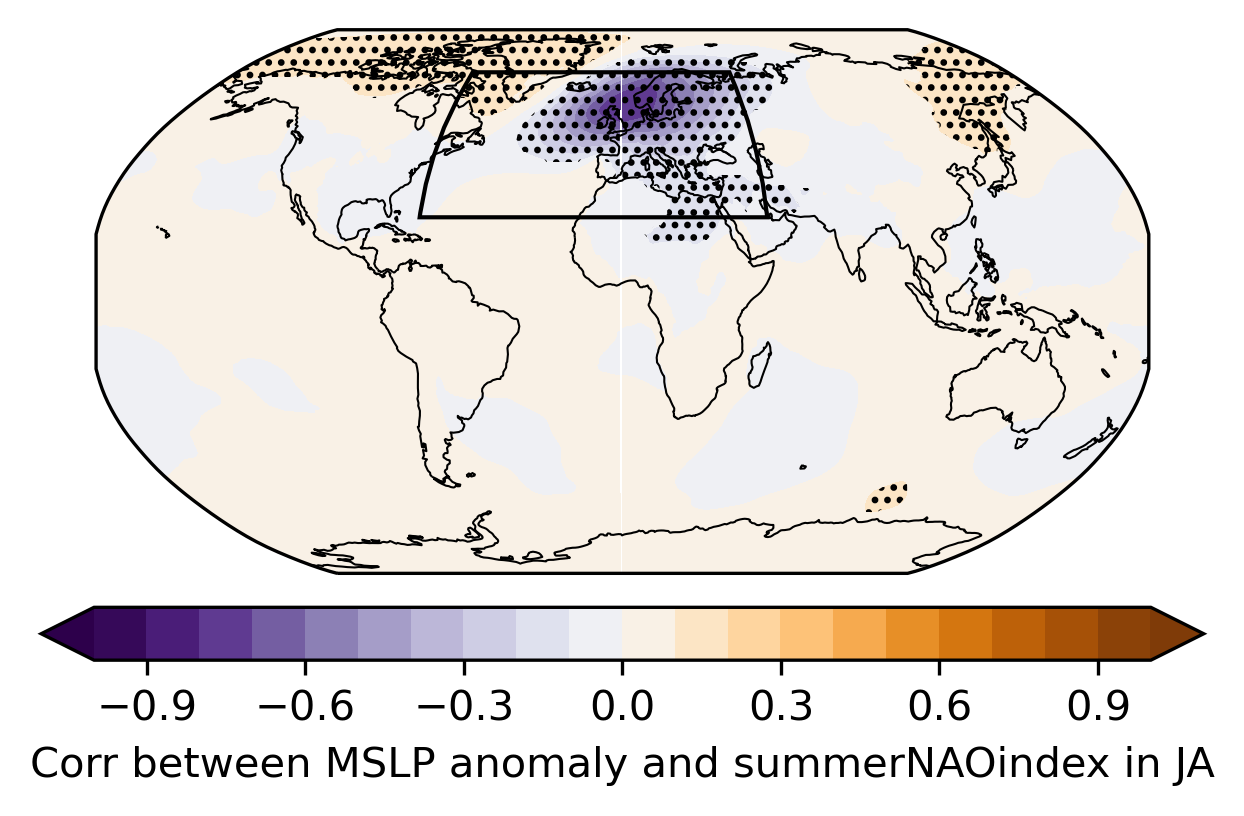

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)


anom = copy.deepcopy(MSLP_JJA_std)
# 1) Reshape space

Nt, Ny, Nx = anom.shape
X = anom.reshape(Nt, Ny * Nx)   # (time, space)

# Handle NaNs safely
valid = np.isfinite(np.nanmean(X, axis=0))
Xv = X[:, valid]

# Demean both fields
Xv = Xv - Xv.mean(axis=0, keepdims=True)
nao = nao_index - nao_index.mean()

# -----------------------------
# 2) Correlation formula
# -----------------------------
num = np.sum(Xv * nao[:, None], axis=0)

den = np.sqrt(
    np.sum(Xv**2, axis=0) *
    np.sum(nao**2)
)

corr_v = num / den   # (Ns_valid,)

# -----------------------------
# 3) Back to map
# -----------------------------
corr_map = np.full(Ny * Nx, np.nan)
corr_map[valid] = corr_v
corr_map = corr_map.reshape(Ny, Nx)

from scipy import stats

dof = Nt - 2
tval = corr_map * np.sqrt(dof / (1 - corr_map**2))
p_map = 2 * (1 - stats.t.cdf(np.abs(tval), dof))

sig_fdr = np.zeros_like(p_map, dtype=bool)
qvals = np.full_like(p_map, np.nan, dtype=float)


p_flat = p_map.ravel()
rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
sig_fdr = rej
qvals = q_flat

effect_mask =np.abs(corr_map)>0.1
sig_final = sig_fdr.reshape((181,360)) & effect_mask



# -------------------------
# 3) Plot: field + hatching where FDR-significant
# -------------------------
fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-1, 1.1, 0.1)
contour = ax.contourf(
    LON_era5, LAT_era5,corr_map,
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap='PuOr_r',
    extend='both'
)

# Hatch overlay (transparent fill, only hatches)
ax.contourf(
    LON_era5, LAT_era5, sig_final.astype(int),
    levels=[0.5, 1.5],
    hatches=['....'],   # density of stippling
    colors='none',
    transform=ccrs.PlateCarree()
)

lon_min = -70
lon_max = 50
lat_min = 25
lat_max = 70
rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)
ax.add_patch(rect)

ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
co.set_label(r'Corr between MSLP anomaly and summerNAOindex in JA')
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

plt.show()


In [112]:

mask_pattern = (LAT_era5<=lat_max)&(LAT_era5>=lat_min)&(LON_era5<=lon_max)&(LON_era5>=lon_min)
ref_pattern = corr_map[mask_pattern]

Summernao_index_all = []
for i in MSLP_std:
    temp_pattern = i[mask_pattern]
    slope, intercept, r, p, stderr = linregress( ref_pattern , temp_pattern)
    Summernao_index_all.append(r)
        

In [117]:
np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_allyear',Summernao_index_all)
np.save('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_JA',nao_index.data)

# Z500 PLOT

In [98]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_Z500_1.x1._3daymean.nc') #current shape = (365, 180,360)

Z500 = np.squeeze(NCData.variables['var129'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()


In [99]:
# Z500_region_clusters  = cluster_regional_mean(Z500)

Z500_JJA = Z500[np.in1d(mon_era5_all,[6,7,8])]
del Z500


In [102]:
time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]


In [103]:

X_std = copy.deepcopy(Z500_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
Z500_JJA_std =copy.deepcopy( X_std)
del X_std

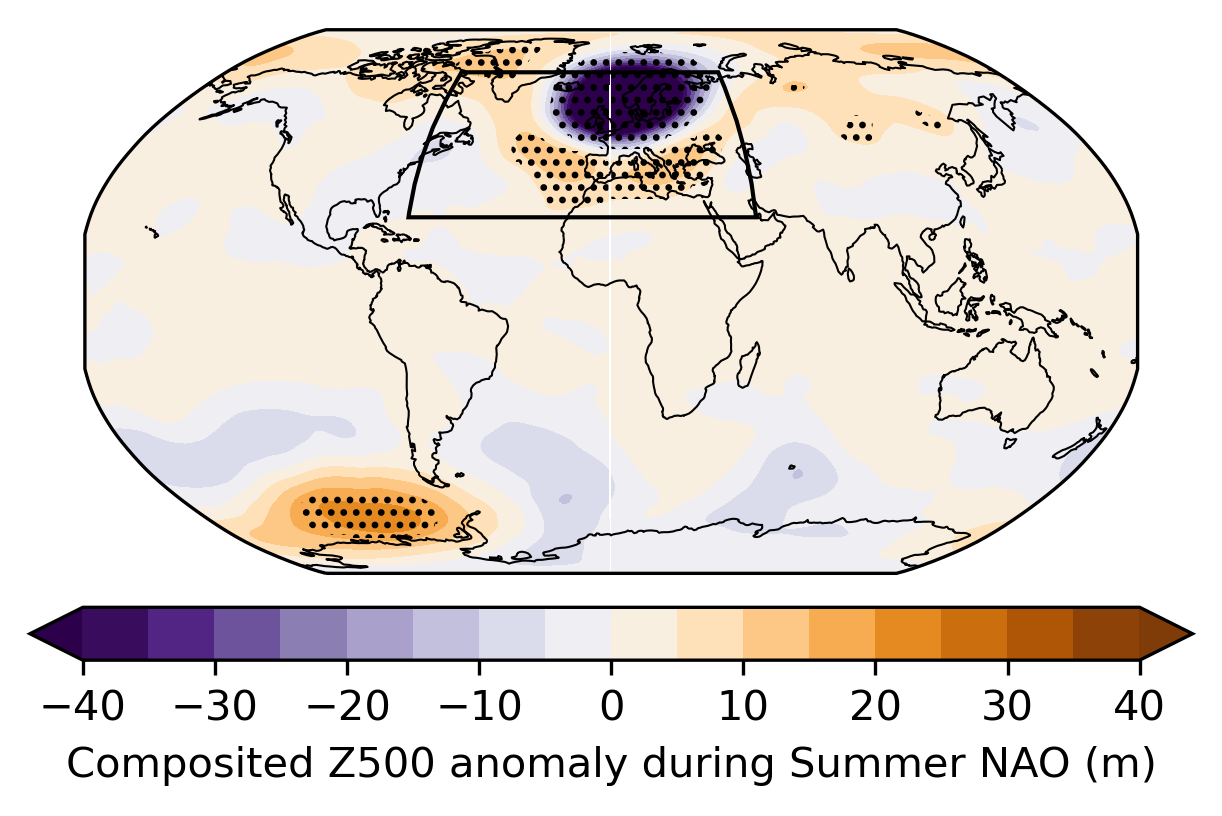

In [104]:
lon3_min_clusters = [-70,-20,-50]
lon3_max_clusters = [40,40,50]
lat3_min_clusters = [35,35,30]
lat3_max_clusters = [70,80,70]

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)
lag = 0          # -1 = one timestep BEFORE the extreme, +1 = after




Z500_region_clusters = np.load('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_allyear.npy',allow_pickle='True')
Z500_temp = Z500_region_clusters[np.in1d(mon_era5_all,[6,7,8])]
Z500_temp_thr = np.nanstd(Z500_temp)

mask_ext = Z500_temp > Z500_temp_thr                # extreme at time t

# -------------------------
# Align lagged masks with Z500
# -------------------------
# For lag=-1: use Z[t] where extreme happens at t+1  (i.e., "one step before")
if lag < 0:
    Z = Z500_JJA_std[:lag, :, :]                   # drop last |lag| times
    mask_ext_lag = mask_ext[-lag:]                 # drop first |lag| times
elif lag > 0:
    Z = Z500_JJA_std[lag:, :, :]                   # drop first lag times
    mask_ext_lag = mask_ext[:-lag]                 # drop last lag times
else:
    Z = Z500_JJA_std
    mask_ext_lag = mask_ext

mask_non_lag = ~mask_ext_lag

# Convert to meters
Z_ext = Z[mask_ext_lag, :, :] / 9.8
Z_non = Z[mask_non_lag, :, :] / 9.8

# Composite anomaly (lagged): extreme-minus-nonextreme
temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z/9.8, axis=0)

# -------------------------
# 1) Gridpoint significance (Welch t-test)
# -------------------------
tstat, pvals = ttest_ind(
    Z_ext, Z_non,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

# Sample-size filter
n_ext = np.sum(np.isfinite(Z_ext), axis=0)
n_non = np.sum(np.isfinite(Z_non), axis=0)
valid = (n_ext >= 10) & (n_non >= 10) & np.isfinite(pvals)

# -------------------------
# 2) FDR across grid points
# -------------------------
sig_fdr = np.zeros_like(pvals, dtype=bool)
qvals = np.full_like(pvals, np.nan, dtype=float)

if np.any(valid):
    p_flat = pvals[valid].ravel()
    rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
    sig_fdr[valid] = rej
    qvals[valid] = q_flat

effect_mask =np.abs(temp_JJA)>5
sig_final = sig_fdr & effect_mask
# -------------------------
# 3) Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-40, 45, 5)
contour = ax.contourf(
    LON_era5, LAT_era5, temp_JJA,
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap='PuOr_r',
    extend='both'
)

ax.contourf(
    LON_era5, LAT_era5, sig_final.astype(int),
    levels=[0.5, 1.5],
    hatches=['....'],
    colors='none',
    transform=ccrs.PlateCarree()
)


rect1 = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    linewidth=1,
    edgecolor='black',
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=10
)
ax.add_patch(rect1)



ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
co.set_label(r'Composited Z500 anomaly during Summer NAO (m)')
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

plt.show()

# Temp PLOT

In [ ]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_T2mmax_1.x1._3daymean.nc') #current shape = (365, 180,360)

T2mmax = np.squeeze(NCData.variables['var167'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()


T2mmax_JJA = T2mmax[np.in1d(mon_era5_all,[6,7,8])]
del T2mmax


time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]


X_std = copy.deepcopy(T2mmax_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
T2mmax_JJA_std =copy.deepcopy( X_std)
del X_std

In [36]:

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)
lag = 0          # -1 = one timestep BEFORE the extreme, +1 = after


SNAO_region_clusters = np.load('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_allyear.npy',allow_pickle='True')
SNAO_temp = SNAO_region_clusters[np.in1d(mon_era5_all,[6,7,8])]
SNAO_temp_thr = np.nanstd(SNAO_temp)

mask_ext = SNAO_temp < -SNAO_temp_thr                # extreme at time t


# -------------------------
# For lag=-1: use Z[t] where extreme happens at t+1  (i.e., "one step before")
if lag < 0:
    Z = T2mmax_JJA_std[:lag, :, :]                   # drop last |lag| times
    mask_ext_lag = mask_ext[-lag:]                 # drop first |lag| times
elif lag > 0:
    Z = T2mmax_JJA_std[lag:, :, :]                   # drop first lag times
    mask_ext_lag = mask_ext[:-lag]                 # drop last lag times
else:
    Z = T2mmax_JJA_std
    mask_ext_lag = mask_ext

mask_non_lag = ~mask_ext_lag



In [37]:

Z_ext = Z[mask_ext_lag, :, :] 
Z_non = Z[mask_non_lag, :, :] 

# Composite anomaly (lagged): extreme-minus-nonextreme
temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z, axis=0)

# -------------------------
# 1) Gridpoint significance (Welch t-test)
# -------------------------
tstat, pvals = ttest_ind(
    Z_ext, Z_non,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

# Sample-size filter
n_ext = np.sum(np.isfinite(Z_ext), axis=0)
n_non = np.sum(np.isfinite(Z_non), axis=0)
valid = (n_ext >= 10) & (n_non >= 10) & np.isfinite(pvals)

# -------------------------
# 2) FDR across grid points
# -------------------------
sig_fdr = np.zeros_like(pvals, dtype=bool)
qvals = np.full_like(pvals, np.nan, dtype=float)

if np.any(valid):
    p_flat = pvals[valid].ravel()
    rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
    sig_fdr[valid] = rej
    qvals[valid] = q_flat



In [41]:
effect_mask =np.abs(temp_JJA)>0.5
sig_final = sig_fdr & effect_mask

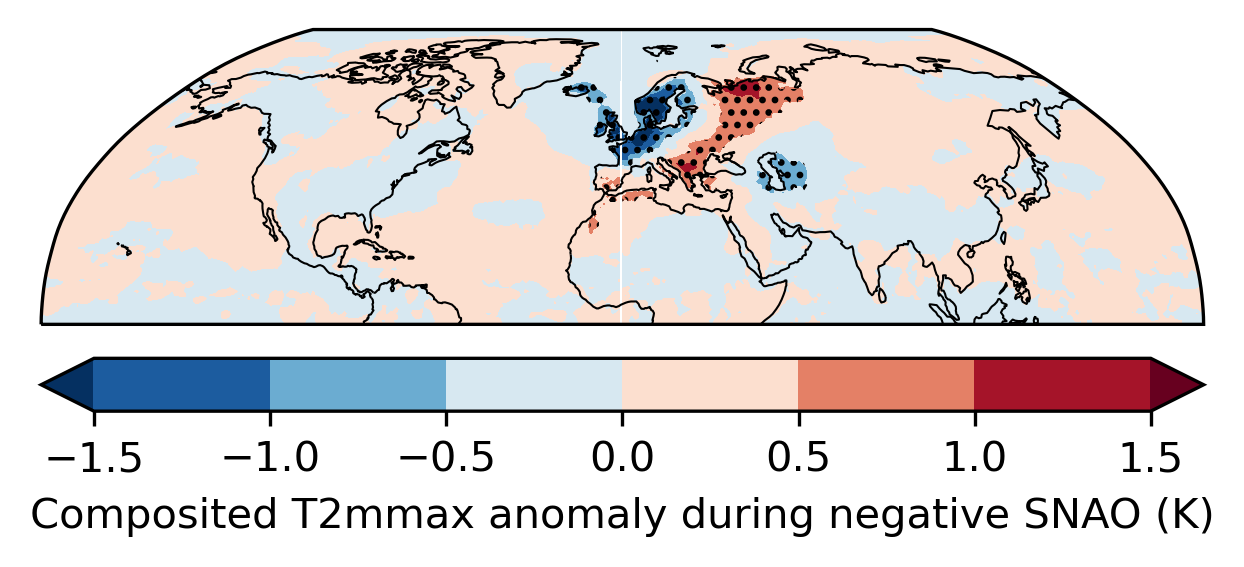

In [42]:
# 3) Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-1.5, 1.55, 0.5)
contour = ax.contourf(
    LON_era5, LAT_era5, temp_JJA,
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    extend='both'
)

ax.contourf(
    LON_era5, LAT_era5, sig_final.astype(int),
    levels=[0.5, 1.5],
    hatches=['....'],
    colors='none',
    transform=ccrs.PlateCarree()
)


# rect1 = mpatches.Rectangle(
#     (lon_min, lat_min),                 # lower-left corner
#     lon_max - lon_min,                  # width
#     lat_max - lat_min,                  # height
#     linewidth=1,
#     edgecolor='black',
#     facecolor='none',
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )
# ax.add_patch(rect1)



ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
co.set_label(r'Composited T2mmax anomaly during negative SNAO (K)')
ax.set_extent([-180, 180, 0, 90], crs=ccrs.PlateCarree())

plt.show()

# Precip PLOT

In [24]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_tot_precip_1.x1._3daymean.nc') #current shape = (365, 180,360)

pr = np.squeeze(NCData.variables['var228'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()


pr_JJA = pr[np.in1d(mon_era5_all,[6,7,8])]
del pr


time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]


X_std = copy.deepcopy(pr_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
pr_JJA_std =copy.deepcopy( X_std)
del X_std

In [25]:

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)
lag = 0          # -1 = one timestep BEFORE the extreme, +1 = after


SNAO_region_clusters = np.load('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_allyear.npy',allow_pickle='True')
SNAO_temp = SNAO_region_clusters[np.in1d(mon_era5_all,[6,7,8])]
SNAO_temp_thr = np.nanstd(SNAO_temp)

mask_ext = SNAO_temp < -SNAO_temp_thr                # extreme at time t


# -------------------------
# For lag=-1: use Z[t] where extreme happens at t+1  (i.e., "one step before")
if lag < 0:
    Z = pr_JJA_std[:lag, :, :]                   # drop last |lag| times
    mask_ext_lag = mask_ext[-lag:]                 # drop first |lag| times
elif lag > 0:
    Z = pr_JJA_std[lag:, :, :]                   # drop first lag times
    mask_ext_lag = mask_ext[:-lag]                 # drop last lag times
else:
    Z = pr_JJA_std
    mask_ext_lag = mask_ext

mask_non_lag = ~mask_ext_lag

In [ ]:

Z_ext = Z[mask_ext_lag, :, :] 
Z_non = Z[mask_non_lag, :, :] 

# Composite anomaly (lagged): extreme-minus-nonextreme
temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z, axis=0)

# -------------------------
# 1) Gridpoint significance (Welch t-test)
# -------------------------
tstat, pvals = ttest_ind(
    Z_ext, Z_non,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

# Sample-size filter
n_ext = np.sum(np.isfinite(Z_ext), axis=0)
n_non = np.sum(np.isfinite(Z_non), axis=0)
valid = (n_ext >= 10) & (n_non >= 10) & np.isfinite(pvals)

# -------------------------
# 2) FDR across grid points
# -------------------------
sig_fdr = np.zeros_like(pvals, dtype=bool)
qvals = np.full_like(pvals, np.nan, dtype=float)

if np.any(valid):
    p_flat = pvals[valid].ravel()
    rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
    sig_fdr[valid] = rej
    qvals[valid] = q_flat



In [34]:
effect_mask =np.abs(temp_JJA)>0.5/24/1000
sig_final = sig_fdr & effect_mask

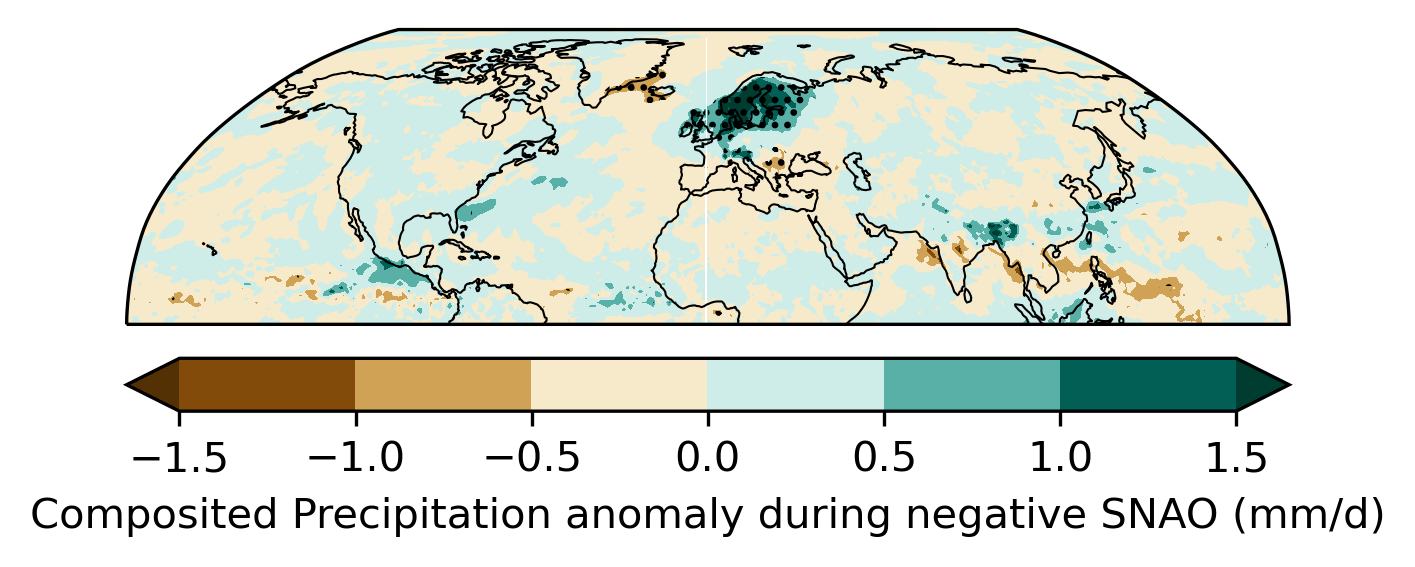

In [35]:
# 3) Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-1.5, 1.55, 0.5)
contour = ax.contourf(
    LON_era5, LAT_era5, temp_JJA*24*1000,
    levels=levels,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    extend='both'
)

ax.contourf(
    LON_era5, LAT_era5, sig_final.astype(int),
    levels=[0.5, 1.5],
    hatches=['....'],
    colors='none',
    transform=ccrs.PlateCarree()
)


# rect1 = mpatches.Rectangle(
#     (lon_min, lat_min),                 # lower-left corner
#     lon_max - lon_min,                  # width
#     lat_max - lat_min,                  # height
#     linewidth=1,
#     edgecolor='black',
#     facecolor='none',
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )
# ax.add_patch(rect1)



ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
co.set_label(r'Composited Precipitation anomaly during negative SNAO (mm/d)')
ax.set_extent([-180, 180, 0, 90], crs=ccrs.PlateCarree())

plt.show()

# windspeed PLOT

In [43]:
# NCData = Dataset(f'/p/projects/ou/rd1/cextremes/data/ERA5/FWI/FWI_cal_'+str(2025)+'_daily.nc') #current shape = (365, 180,360)
NCData = Dataset(f'/p/projects/ou/rd1/cextremes/ytian/data/ERA5_globe_1950_2025/ERA5_1950_2025_wind10_1.x1._3daymean.nc') #current shape = (365, 180,360)

wind10 = np.squeeze(NCData.variables['wind10'][:])
lon_era5= NCData.variables['lon'][:]
lat_era5 = NCData.variables['lat'][:]
LON_era5, LAT_era5 = np.meshgrid(lon_era5, lat_era5)
time = NCData.variables['time']
dates = list(num2date(time[:], time.units, time.calendar))
year_era5_all = np.array([date.year for date in dates])
mon_era5_all = np.array([date.month for date in dates])
day_era5_all = np.array([date.day for date in dates])

NCData.close()

In [44]:
wind10_JJA = wind10[np.in1d(mon_era5_all,[6,7,8])]
del wind10


time_mask = (np.in1d(mon_era5_all,[6,7,8]))
year_era5_all_JJA = year_era5_all[time_mask ]
mon_era5_all_JJA = mon_era5_all[time_mask ]
day_era5_all_JJA = day_era5_all[time_mask ]


X_std = copy.deepcopy(wind10_JJA)
for i_mon in set(mon_era5_all_JJA):
    mu  = np.nanmean(X_std[mon_era5_all_JJA==i_mon] , axis=0, keepdims=True)
    X_std[mon_era5_all_JJA==i_mon] = X_std[mon_era5_all_JJA==i_mon] -mu

for i_year in set(year_era5_all_JJA):
    mu  = np.nanmean(X_std[year_era5_all_JJA==i_year] , axis=0, keepdims=True)
    X_std[year_era5_all_JJA==i_year] = X_std[year_era5_all_JJA==i_year] -mu
    
wind10_JJA_std =copy.deepcopy( X_std)
del X_std

In [45]:

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

alpha_fdr = 0.05  # FDR threshold (q-value)
lag = 0          # -1 = one timestep BEFORE the extreme, +1 = after


SNAO_region_clusters = np.load('/p/projects/ou/rd1/cextremes/ytian/results_wildfire/MED/summerNAO_index_1950_2025_3d_allyear.npy',allow_pickle='True')
SNAO_temp = SNAO_region_clusters[np.in1d(mon_era5_all,[6,7,8])]
SNAO_temp_thr = np.nanstd(SNAO_temp)

mask_ext = SNAO_temp < -SNAO_temp_thr                # extreme at time t


# -------------------------
# For lag=-1: use Z[t] where extreme happens at t+1  (i.e., "one step before")
if lag < 0:
    Z = wind10_JJA_std[:lag, :, :]                   # drop last |lag| times
    mask_ext_lag = mask_ext[-lag:]                 # drop first |lag| times
elif lag > 0:
    Z = wind10_JJA_std[lag:, :, :]                   # drop first lag times
    mask_ext_lag = mask_ext[:-lag]                 # drop last lag times
else:
    Z = wind10_JJA_std
    mask_ext_lag = mask_ext

mask_non_lag = ~mask_ext_lag

In [46]:

Z_ext = Z[mask_ext_lag, :, :] 
Z_non = Z[mask_non_lag, :, :] 

# Composite anomaly (lagged): extreme-minus-nonextreme
temp_JJA = np.nanmean(Z_ext, axis=0) - np.nanmean(Z, axis=0)

# -------------------------
# 1) Gridpoint significance (Welch t-test)
# -------------------------
tstat, pvals = ttest_ind(
    Z_ext, Z_non,
    axis=0,
    equal_var=False,
    nan_policy="omit"
)

# Sample-size filter
n_ext = np.sum(np.isfinite(Z_ext), axis=0)
n_non = np.sum(np.isfinite(Z_non), axis=0)
valid = (n_ext >= 10) & (n_non >= 10) & np.isfinite(pvals)

# -------------------------
# 2) FDR across grid points
# -------------------------
sig_fdr = np.zeros_like(pvals, dtype=bool)
qvals = np.full_like(pvals, np.nan, dtype=float)

if np.any(valid):
    p_flat = pvals[valid].ravel()
    rej, q_flat, _, _ = multipletests(p_flat, alpha=alpha_fdr, method="fdr_bh")
    sig_fdr[valid] = rej
    qvals[valid] = q_flat


In [49]:
effect_mask =np.abs(temp_JJA)>0.05
sig_final = sig_fdr & effect_mask

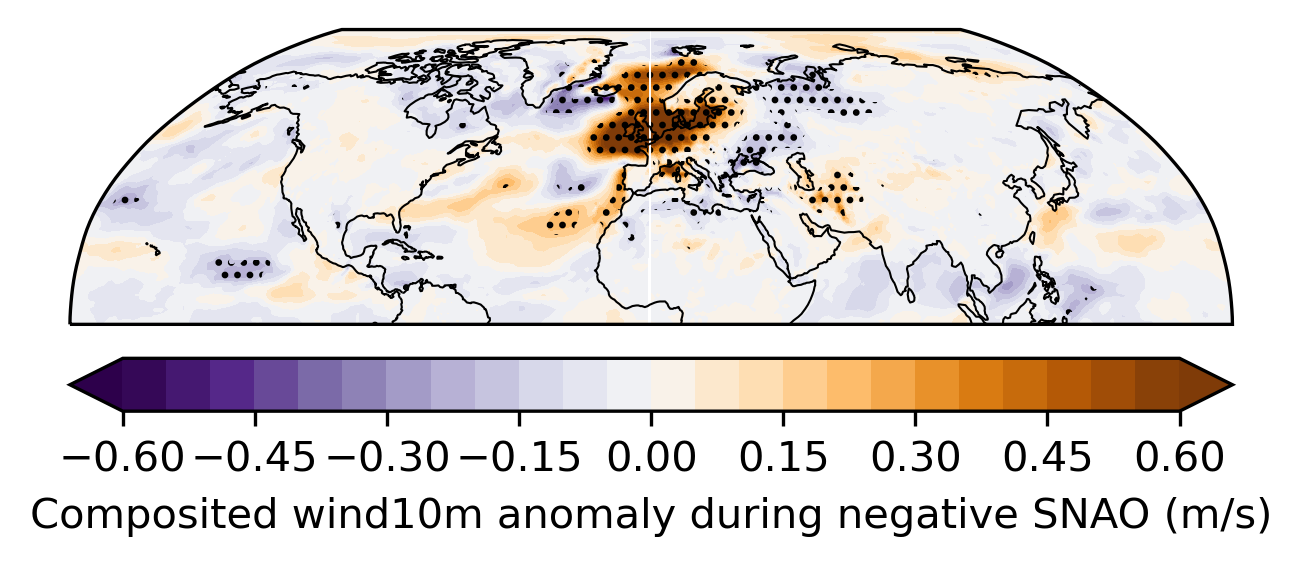

In [51]:
# 3) Plot
# -------------------------
fig, ax = plt.subplots(figsize=(5,3), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
fig.patch.set_alpha(0)

levels = np.arange(-0.6, 0.65, 0.05)
contour = ax.contourf(
    LON_era5, LAT_era5, temp_JJA,
     levels=levels,
    transform=ccrs.PlateCarree(),
    cmap='PuOr_r',
    extend='both'
)

ax.contourf(
    LON_era5, LAT_era5, sig_final.astype(int),
    levels=[0.5, 1.5],
    hatches=['....'],
    colors='none',
    transform=ccrs.PlateCarree()
)


# rect1 = mpatches.Rectangle(
#     (lon_min, lat_min),                 # lower-left corner
#     lon_max - lon_min,                  # width
#     lat_max - lat_min,                  # height
#     linewidth=1,
#     edgecolor='black',
#     facecolor='none',
#     transform=ccrs.PlateCarree(),
#     zorder=10
# )
# ax.add_patch(rect1)



ax.coastlines(linewidth=0.5)
co = plt.colorbar(contour, ax=ax, orientation='horizontal', pad=0.05)
co.set_label(r'Composited wind10m anomaly during negative SNAO (m/s)')
ax.set_extent([-180, 180, 0, 90], crs=ccrs.PlateCarree())

plt.show()